# Quantização de Imagens em Tons de Cinza

Neste notebook, com base no material desenvolvido em sala, carregamos uma imagem, convertemos para tons de cinza e geramos versões quantizadas com diferentes quantidades de bits (1, 2, 4 e 8 bits), implementando a quantização manualmente com NumPy.

In [5]:
import cv2 # OpenCV
import numpy as np # Funções matemáticas
import matplotlib.pyplot as plt # Exibição das imagens
from google.colab import files

## 1. Carregando a imagem escolhida

Foi escolhida a imagem `imagem_escolhida.jpg` (foto da astronauta Eileen Collins).

In [6]:
arquivo = files.upload()

Saving imagem_escolhida.jpg to imagem_escolhida.jpg


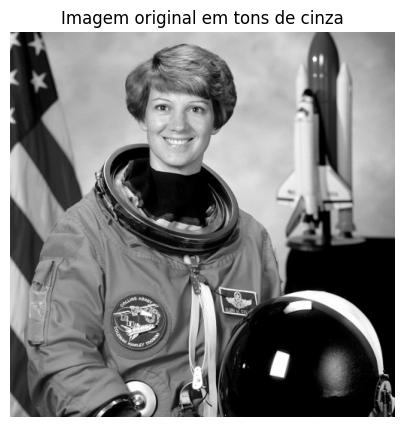

In [7]:
img_bgr = cv2.imread('imagem_escolhida.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(img_gray, cmap='gray')
plt.title('Imagem original em tons de cinza')
plt.axis('off')
plt.show()

## 2. Implementando a quantização com NumPy

A quantização consiste em reduzir a quantidade de níveis de intensidade da imagem. Para uma imagem com `n` bits por pixel, temos `2**n` níveis possíveis.

A ideia da implementação é:
1. Calcular o "fator" de agrupamento: `256 // niveis` (quantos valores de 0-255 caem em cada nível quantizado);
2. Usar divisão inteira (`//`) para descobrir em qual nível cada pixel se encaixa;
3. Multiplicar de volta pelo fator, obtendo o valor representativo daquele nível.

Tudo isso é feito apenas com operações aritméticas sobre o array NumPy da imagem, sem usar nenhuma função pronta de quantização.

In [8]:
def quantizar(img, bits):
    niveis = 2 ** bits              # quantidade de níveis de intensidade
    fator = 256 // niveis           # tamanho de cada "faixa" de intensidade

    # divisão inteira: descobre em qual faixa (nível) cada pixel se encaixa
    # e multiplica de volta pelo fator para obter o valor representativo do nível
    img_quant = (img.astype(np.uint16) // fator) * fator

    return img_quant.astype(np.uint8)

# Gerando as versões quantizadas
img_1bit = quantizar(img_gray, 1)   # 2 níveis
img_2bit = quantizar(img_gray, 2)   # 4 níveis
img_4bit = quantizar(img_gray, 4)   # 16 níveis
img_8bit = quantizar(img_gray, 8)   # 256 níveis (praticamente igual à original)

## 3. Exibindo a imagem original e as versões quantizadas

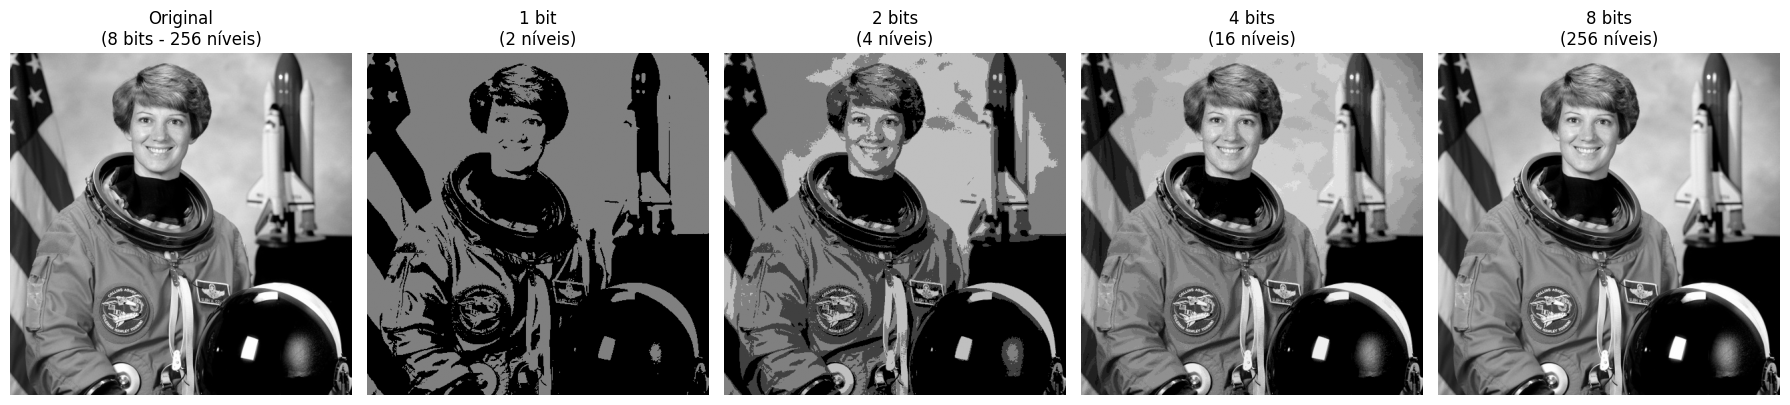

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(18, 4))

ax[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original\n(8 bits - 256 níveis)')
ax[0].axis('off')

ax[1].imshow(img_1bit, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('1 bit\n(2 níveis)')
ax[1].axis('off')

ax[2].imshow(img_2bit, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('2 bits\n(4 níveis)')
ax[2].axis('off')

ax[3].imshow(img_4bit, cmap='gray', vmin=0, vmax=255)
ax[3].set_title('4 bits\n(16 níveis)')
ax[3].axis('off')

ax[4].imshow(img_8bit, cmap='gray', vmin=0, vmax=255)
ax[4].set_title('8 bits\n(256 níveis)')
ax[4].axis('off')

plt.tight_layout()
plt.savefig('quantizacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Discussão

**O que acontece com os detalhes e com as transições de intensidade da imagem à medida que reduzimos o número de bits?**

À medida que reduzimos o número de bits (e, consequentemente, o número de níveis de intensidade disponíveis), a imagem perde detalhes finos: regiões que antes tinham variações sutis de tom passam a ser representadas por um único valor de cinza, fazendo com que texturas e pequenos contrastes desapareçam. As transições de intensidade, que originalmente eram suaves e graduais (como na imagem de 8 bits), tornam-se abruptas, formando contornos visíveis entre regiões de cores uniformes, um efeito conhecido como posterização ou falso contorno (false contouring). Com apenas 1 bit (2 níveis), a imagem fica reduzida a duas cores (preto e branco), preservando apenas as informações mais grosseiras de forma/silhueta e perdendo quase toda a informação de textura e sombreado. Já com 8 bits, a imagem é praticamente indistinguível da original, pois o número de níveis (256) é suficiente para representar transições suaves ao olho humano.